In [1]:

import numpy as np
import scipy as sp
from scipy import signal
from scipy.fft import fft, fftshift
import matplotlib.pyplot as plt
 
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


Zero padding means extending a signal $x[n]$ with additional zeros to reach a desired signal length.
This is often done before applying a FFT if an input signal does not have a power-of-two length,
for example in an STFT with a specific window duration specified in $\mathrm{ms}$.
Many FFT and STFT libraries and modules will automatically zero-pad.

The following plot shows a Hann window with a length of $N=700$ samples, that is zero padded to a length of $1024$ samples.

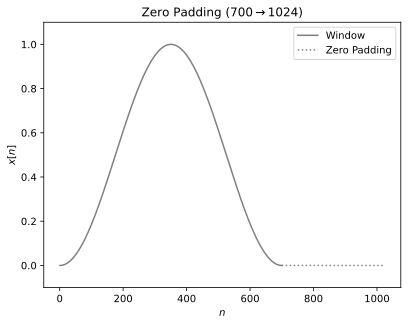

In [2]:
N  = 700

n1 = np.linspace(1,N,N)

n2  = np.linspace(N,N+324,324)
pad = np.zeros(324)

w = signal.windows.hann(N)
# w = np.append(w,np.zeros(10))
# w = np.append(np.zeros(10),w)

plt.plot(n1, w,'gray', label="Window")
plt.plot(n2, pad,'gray',linestyle=':', label='Zero Padding')
plt.ylim([-0.1,1.1])

plt.legend()
plt.title("Zero Padding ($700 \\rightarrow 1024$)")
plt.ylabel("$x[n]$")
plt.xlabel("$n$");




-----

# Effect and Benefit

From the introduction to the Discrete Fourier Transform we know that the frequency resolution of the resulting 
frequency domain signal depends on the input length $N$ and the sampling rate $f_s$.
The distance between neighboring bins is calculated as follows;

$$
\Delta_f = \frac{f_s}{N}
$$

Increasing the length of $N$ of the signal reduces $\Delta_f$.

The plot below shows $x[n]$, a windowed sine wave with a fundamental frequency $f_0=107.5$, a length of $N=2048$ samples at a sampling rate of $f_s=8000$. 

$x^*[n]$ is a version of the same signal, padded to a length of $N^*=4096$:

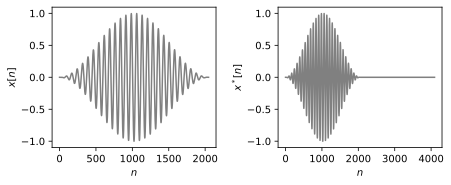

In [3]:
fs = 8000
N  = 2048
N2 = 4096
P  = N2-N


n1 = np.linspace(0,N/fs,N)
n2 = np.linspace(0,N2/fs,N2)

pad = np.zeros(P)

w1 = signal.windows.hann(N)*(np.sin(2*np.pi*107.5*n1)+0)

w2 = np.append(w1, pad)

W1 = abs(np.fft.fft(w1))[0:int(N/2)]
W2 = abs(np.fft.fft(w2))[0:int(N2/2)]


plt.subplot(221)
plt.plot(w1,'gray', label="Window")
plt.xlabel('$n$')
plt.ylabel('$x[n]$')
#plt.ylim([-0.1,1.1])

plt.subplot(222)
plt.plot(w2,'gray', label="Window")
#plt.ylim([-0.1,1.1])
plt.xlabel('$n$')
plt.ylabel('$x^*[n]$')


plt.tight_layout()

plt.show()

## DFT

The results of the DFT for the original and the padded signal are shown below.

- $|X|$ shows the typical (smeared) peak of the sinusoid.

- $|X^*|$ shows additional sidelobes - this is the effect of the windowing: the window gets narrower in the time domain through the padding.


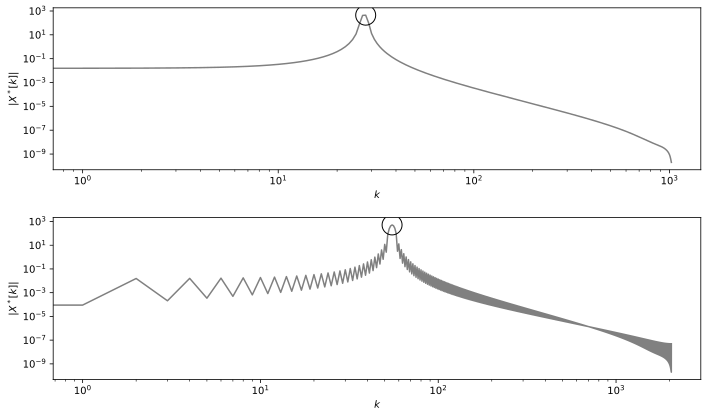

In [4]:
plt.figure(figsize=(10, 6))


# Find peaks
peaks, _ = signal.find_peaks(W1,height=10e1)
# Plot the data and peaks
#print(peaks*(fs/N))

plt.subplot(211)
plt.loglog(W1,'gray', label="Window")
plt.plot(peaks, W1[peaks], "o", markersize=20, markerfacecolor='none', color='k', label='Peaks')
plt.xlabel('$k$')
plt.ylabel('$|X^*[k]|$')

# Find peaks
peaks, _ = signal.find_peaks(W2,height=10e1)
# Plot the data and peaks
#print(peaks*(fs/N2))

plt.subplot(212)
plt.loglog(W2,'gray', label="Window");
plt.plot(peaks, W2[peaks], "o", markersize=20, markerfacecolor='none', color='k', label='Peaks')
plt.xlabel('$k$')
plt.ylabel('$|X^*[k]|$')

plt.tight_layout()

#plt.legend()
#plt.title("Zero Padding ($700 \\rightarrow 1024$)")
#plt.ylabel("$x[n]$")
#plt.xlabel("$n$");


More importantly, we see that the peak appears to be smoother for $|X^*|$. This is one of the reasons for applying zero-padding in many analysis applications. **The increased density of frequency bins allows a more accurate estimation of peaks in the magnitute spectrogram.**

For $|X|$, the highest peak is detected at $n=28$:

$$
f_0 = \frac{f_s}{N} = 28 \frac{8000 \mathrm{Hz}}{2048} = \mathbf{109.375 \mathrm{Hz}}
$$

For $|X^*|$, the highest peak is detected at $n=55$:

$$
f_0 = \frac{f_s}{N^*} = 55 \frac{8000 \mathrm{Hz}}{4096} = \mathbf{107.42 \mathrm{Hz}}
$$

The latter value is closer to the $107.5$ of the input signal.
Note that a similar improvement of the peak estimation would be possible with polynominal interpolation on $|X|$.


-----

# Interpretation

Zero padding does not add information and - although it does decrease $\Delta_f$ - does not increase the true frequency resolution.
What happens, can be explained in the DFT equation:

$$
\begin{eqnarray}
X[k] & = & \sum\limits_{n=0}^{N-1} x[n] e^{-j 2 \pi k \frac{n}{N}} \\
\end{eqnarray}
$$

By zero-padding, we are increasing $N$. This adds additional complex oscillations to compare the signal with.
We are thus adding bins in between the bins of the un-padded DFT.
This can be written as:

$$
\begin{eqnarray}
X[k] & = & \sum\limits_{n=0}^{N^*-1} x^*[n] e^{-j 2 \pi k \frac{n}{N^*}} \\
\end{eqnarray}
$$


------

## Fractional DFT

The same result as with zero padding can be achieved by changing how the DFT treats the frequency index $k$.
Normally it is assumed that:

$$
k \in \{0,1,2,…,N-1\}
$$

We can also use fractional values $\hat{k}$, which is equivalent to upsampling.
For the ratio $r = \frac{N}{N^*}$, this results in:

$$
\hat{k} \in \{0r,1r,2 r,…,(N^* r)-1\} = \{0,0.5,1,…,N-1\}
$$

$$
\begin{eqnarray}
X[\hat{k}] & = & \sum\limits_{n=0}^{N-1} x[n] e^{-j 2 \pi \hat{k} \frac{n}{N}} \\
\end{eqnarray}
$$

The concept for alternative bin-spacings is used in other transforms,
such as the constant-Q transform.

----

## Comparison

The plots below show the results of the zero-padded DFT and the fractional DSP for comparison.
Both algorithms result in the same magnitude spectrum.
The benefits of FFTs might not apply for the fractional DFT case.


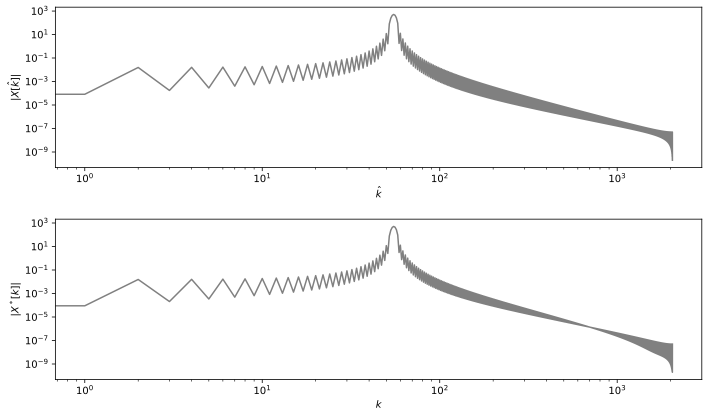

In [6]:
plt.figure(figsize=(10, 6))


def ffft(x, N):

    NN = len(x)
    n  = np.linspace(0,NN,NN)
    n  = n/N
    XR = np.zeros([N])
    XI = np.zeros([N])

    for k in range(N):

        real = np.cos(2 * np.pi * k * n)
        imag = np.sin(2 * np.pi * k * n)    
        
        XR[k] = sum(x*real)
        XI[k] = sum(x*imag)
        
    plt.loglog(np.sqrt(XR*XR + XI*XI)[0:int(N/2)],'gray', label="Window") 



plt.subplot(2,1,1)
ffft(w1,N2)
#plt.ylim([-0.1,1.1])
plt.xlabel('$\hat{k}$')
plt.ylabel('$|X[\hat{k}]|$')

plt.subplot(212)
plt.loglog(W2,'gray', label="Window")
#plt.ylim([-0.1,1.1])
plt.xlabel('$k$')
plt.ylabel('$|X^*[k]|$')

plt.tight_layout()
